# Station Clustering by Temporal Demand Profile
**NYC Bikers: The Pulse of the City**

Clusters Citi Bike stations into functional archetypes — *Commuter Hub, Residential,
Nightlife, Tourist, etc.* — using only their hourly usage patterns.

**Approach:**
1. Build a 48-dimensional feature vector per station (24h departures + 24h arrivals),
    split by weekday vs. weekend
2. Normalize profiles so volume doesn't dominate shape
3. K-means clustering (with elbow/silhouette for k selection)
4. Visualize cluster archetypes + map them onto NYC

*Inspired by the Vélib' 2017 K-means paper, Lee & Leung 2023, and chaddling/bikeshareTO.*


## 0. Setup

In [0]:
import pyspark.sql.functions as F
from pyspark.sql.functions import col, count, hour, dayofweek

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

## 1. Load data & add time features

In [0]:

df = spark.table("citibike.trips")

# Add hour and weekday/weekend flag
df = (
    df
    .withColumn("hour", hour("started_at"))
    .withColumn("dow", dayofweek("started_at"))          # 1=Sun ... 7=Sat
    .withColumn("is_weekend", col("dow").isin(1, 7).cast("int"))
)

print(f"Total trips: {df.count():,}")
df.select("started_at", "hour", "dow", "is_weekend").show(5)


Total trips: 10,104,477
+--------------------+----+---+----------+
|          started_at|hour|dow|is_weekend|
+--------------------+----+---+----------+
|2025-08-06 07:41:...|   7|  4|         0|
|2025-08-13 07:43:...|   7|  4|         0|
|2025-08-04 16:34:...|  16|  2|         0|
|2025-08-05 16:50:...|  16|  3|         0|
|2025-08-08 18:14:...|  18|  6|         0|
+--------------------+----+---+----------+
only showing top 5 rows


## 2. Build station hourly profiles (Spark aggregation)

For each station we compute **4 profiles × 24 hours = 96 features**:
- Weekday departures by hour (0-23)
- Weekday arrivals by hour (0-23)
- Weekend departures by hour (0-23)
- Weekend arrivals by hour (0-23)

This all runs in Spark on the full 10M-row dataset.

In [0]:
# --- Departures ---
deps = (
    df
    .filter(col("start_station_name").isNotNull())
    .groupBy("start_station_name", "start_lat", "start_lng", "is_weekend", "hour")
    .agg(count("*").alias("dep_count"))
    .withColumnRenamed("start_station_name", "station_name")
    .withColumnRenamed("start_lat", "lat")
    .withColumnRenamed("start_lng", "lng")
)

# --- Arrivals ---
arrs = (
    df
    .filter(col("end_station_name").isNotNull())
    .groupBy("end_station_name", "end_lat", "end_lng", "is_weekend", "hour")
    .agg(count("*").alias("arr_count"))
    .withColumnRenamed("end_station_name", "station_name")
    .withColumnRenamed("end_lat", "lat")
    .withColumnRenamed("end_lng", "lng")
)

print("Departure groups:", deps.count())
print("Arrival groups:",   arrs.count())

Departure groups: 100795
Arrival groups: 102090


### Pivot into wide format
We pivot so each station becomes one row with columns like
`dep_wd_0, dep_wd_1, ... dep_wd_23, dep_we_0, ... arr_wd_0, ...`


In [0]:
def pivot_profile(sdf, count_col, prefix):
    """
    Pivot a (station, is_weekend, hour, count) DataFrame into wide format.
    Returns columns: station_name, lat, lng, {prefix}_wd_0 ... {prefix}_we_23
    """
    # Compose a label column: "wd_7" or "we_14"
    sdf = sdf.withColumn(
        "label",
        F.concat(
            F.when(col("is_weekend") == 0, F.lit("wd")).otherwise(F.lit("we")),
            F.lit("_"),
            col("hour").cast("string")
        )
    )

    # Get canonical station lat/lng (mode via first)
    coords = (
        sdf
        .groupBy("station_name")
        .agg(
            F.first("lat", ignorenulls=True).alias("lat"),
            F.first("lng", ignorenulls=True).alias("lng"),
        )
    )

    pivoted = (
        sdf
        .groupBy("station_name")
        .pivot("label")
        .agg(F.sum(count_col))
        .fillna(0)
    )

    # Rename pivoted columns with prefix
    for c in pivoted.columns:
        if c != "station_name":
            pivoted = pivoted.withColumnRenamed(c, f"{prefix}_{c}")

    return pivoted.join(coords, on="station_name", how="left")


dep_wide = pivot_profile(deps, "dep_count", "dep")
arr_wide = pivot_profile(arrs, "arr_count", "arr")

# Join departures + arrivals on station name
station_profiles = dep_wide.join(
    arr_wide.drop("lat", "lng"),
    on="station_name",
    how="outer"
).fillna(0)

print(f"Stations with profiles: {station_profiles.count()}")
station_profiles.printSchema()

Stations with profiles: 2225
root
 |-- station_name: string (nullable = true)
 |-- dep_wd_0: long (nullable = false)
 |-- dep_wd_1: long (nullable = false)
 |-- dep_wd_10: long (nullable = false)
 |-- dep_wd_11: long (nullable = false)
 |-- dep_wd_12: long (nullable = false)
 |-- dep_wd_13: long (nullable = false)
 |-- dep_wd_14: long (nullable = false)
 |-- dep_wd_15: long (nullable = false)
 |-- dep_wd_16: long (nullable = false)
 |-- dep_wd_17: long (nullable = false)
 |-- dep_wd_18: long (nullable = false)
 |-- dep_wd_19: long (nullable = false)
 |-- dep_wd_2: long (nullable = false)
 |-- dep_wd_20: long (nullable = false)
 |-- dep_wd_21: long (nullable = false)
 |-- dep_wd_22: long (nullable = false)
 |-- dep_wd_23: long (nullable = false)
 |-- dep_wd_3: long (nullable = false)
 |-- dep_wd_4: long (nullable = false)
 |-- dep_wd_5: long (nullable = false)
 |-- dep_wd_6: long (nullable = false)
 |-- dep_wd_7: long (nullable = false)
 |-- dep_wd_8: long (nullable = false)
 |-- dep_wd

## 3. Move to pandas for clustering

The station-level summary is tiny (~2K rows), so pandas + sklearn is the
right tool from here.

In [0]:

pdf = station_profiles.toPandas()

# Identify feature columns (everything except station_name, lat, lng)
meta_cols = ["station_name", "lat", "lng"]
feature_cols = sorted([c for c in pdf.columns if c not in meta_cols])
print(f"Feature dimensions: {len(feature_cols)}")

# Fill any remaining NaN and cast
pdf[feature_cols] = pdf[feature_cols].fillna(0).astype(float)

# Filter out very low-activity stations (noise)
pdf["total_trips"] = pdf[feature_cols].sum(axis=1)
min_trips = pdf["total_trips"].quantile(0.05)
print(f"Filtering stations with < {min_trips:.0f} total trips (5th percentile)")
pdf_active = pdf[pdf["total_trips"] >= min_trips].copy()
print(f"Active stations: {len(pdf_active)}")

Feature dimensions: 96
Filtering stations with < 474 total trips (5th percentile)
Active stations: 2113


### Normalize: shape matters more than volume

We L1-normalize each station's profile so it sums to 1 (a probability
distribution over hours), then StandardScale for K-means.
This ensures a small residential station and a huge residential station
cluster together based on *when* people ride, not *how many*.


In [0]:
X_raw = pdf_active[feature_cols].values

# L1 normalize each row (make it a proportion)
row_sums = X_raw.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid /0
X_norm = X_raw / row_sums

# Then standard-scale columns for K-means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

print(f"Feature matrix shape: {X_scaled.shape}")


Feature matrix shape: (2113, 96)


## 4. Choose k — Elbow + Silhouette

In [0]:

K_RANGE = range(2, 11)
inertias = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"  k={k:2d}  |  inertia={km.inertia_:,.0f}  |  silhouette={sil_scores[-1]:.4f}")


  k= 2  |  inertia=183,458  |  silhouette=0.1025
  k= 3  |  inertia=172,532  |  silhouette=0.0814
  k= 4  |  inertia=165,945  |  silhouette=0.0410
  k= 5  |  inertia=161,090  |  silhouette=0.0666
  k= 6  |  inertia=157,074  |  silhouette=0.0691
  k= 7  |  inertia=154,040  |  silhouette=0.0239
  k= 8  |  inertia=150,824  |  silhouette=0.0290
  k= 9  |  inertia=148,447  |  silhouette=0.0253
  k=10  |  inertia=146,767  |  silhouette=0.0217


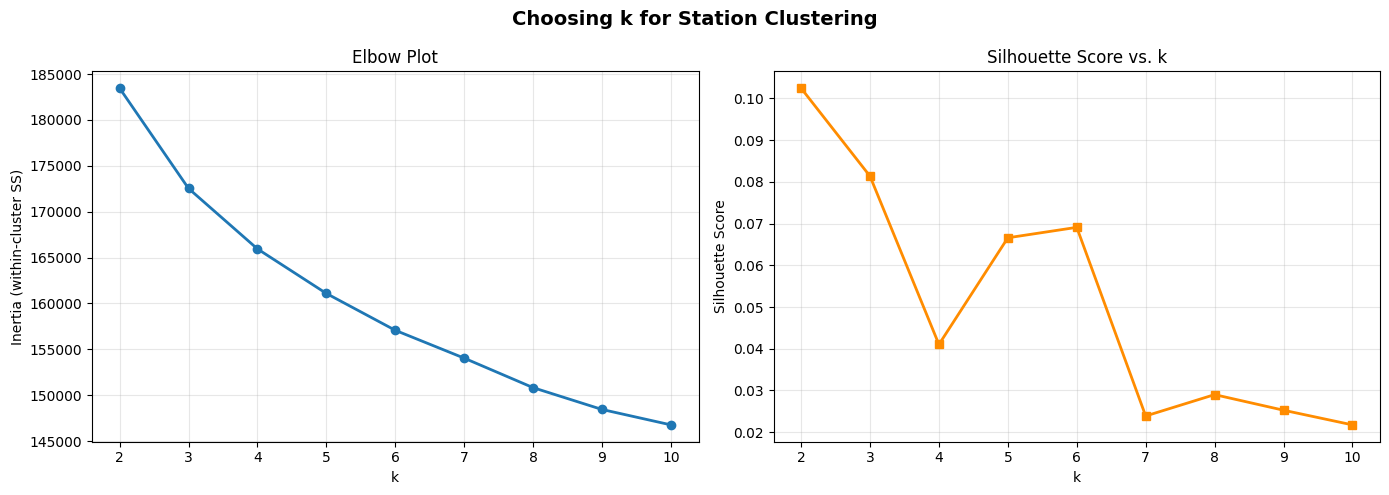

In [0]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inertias, "o-", linewidth=2)
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia (within-cluster SS)")
ax1.set_title("Elbow Plot")
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), sil_scores, "s-", linewidth=2, color="darkorange")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score vs. k")
ax2.grid(True, alpha=0.3)

fig.suptitle("Choosing k for Station Clustering", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Pick your k below based on the plots above
Look for the elbow (diminishing returns in inertia) and the peak silhouette.
**k=4 or k=5 typically works well** for bike-share temporal clustering.

In [0]:
CHOSEN_K = 6  # <-- adjust after inspecting the plots

km_final = KMeans(n_clusters=CHOSEN_K, n_init=20, random_state=42)
pdf_active["cluster"] = km_final.fit_predict(X_scaled)

print(pdf_active["cluster"].value_counts().sort_index())

cluster
0    767
1    400
2    150
3    462
4    124
5    210
Name: count, dtype: int64


## 5. Visualize cluster archetypes

Plot the **average hourly profile** for each cluster — this is where you see
"Commuter Hub" (AM/PM peaks), "Residential" (inverse), "Tourist" (midday
hump), "Nightlife" (late evening), etc.

In [0]:
# Build a tidy DataFrame of normalized profiles + cluster
profile_df = pd.DataFrame(X_norm, columns=feature_cols, index=pdf_active.index)
profile_df["cluster"] = pdf_active["cluster"].values

# Compute cluster means
cluster_means = profile_df.groupby("cluster").mean()

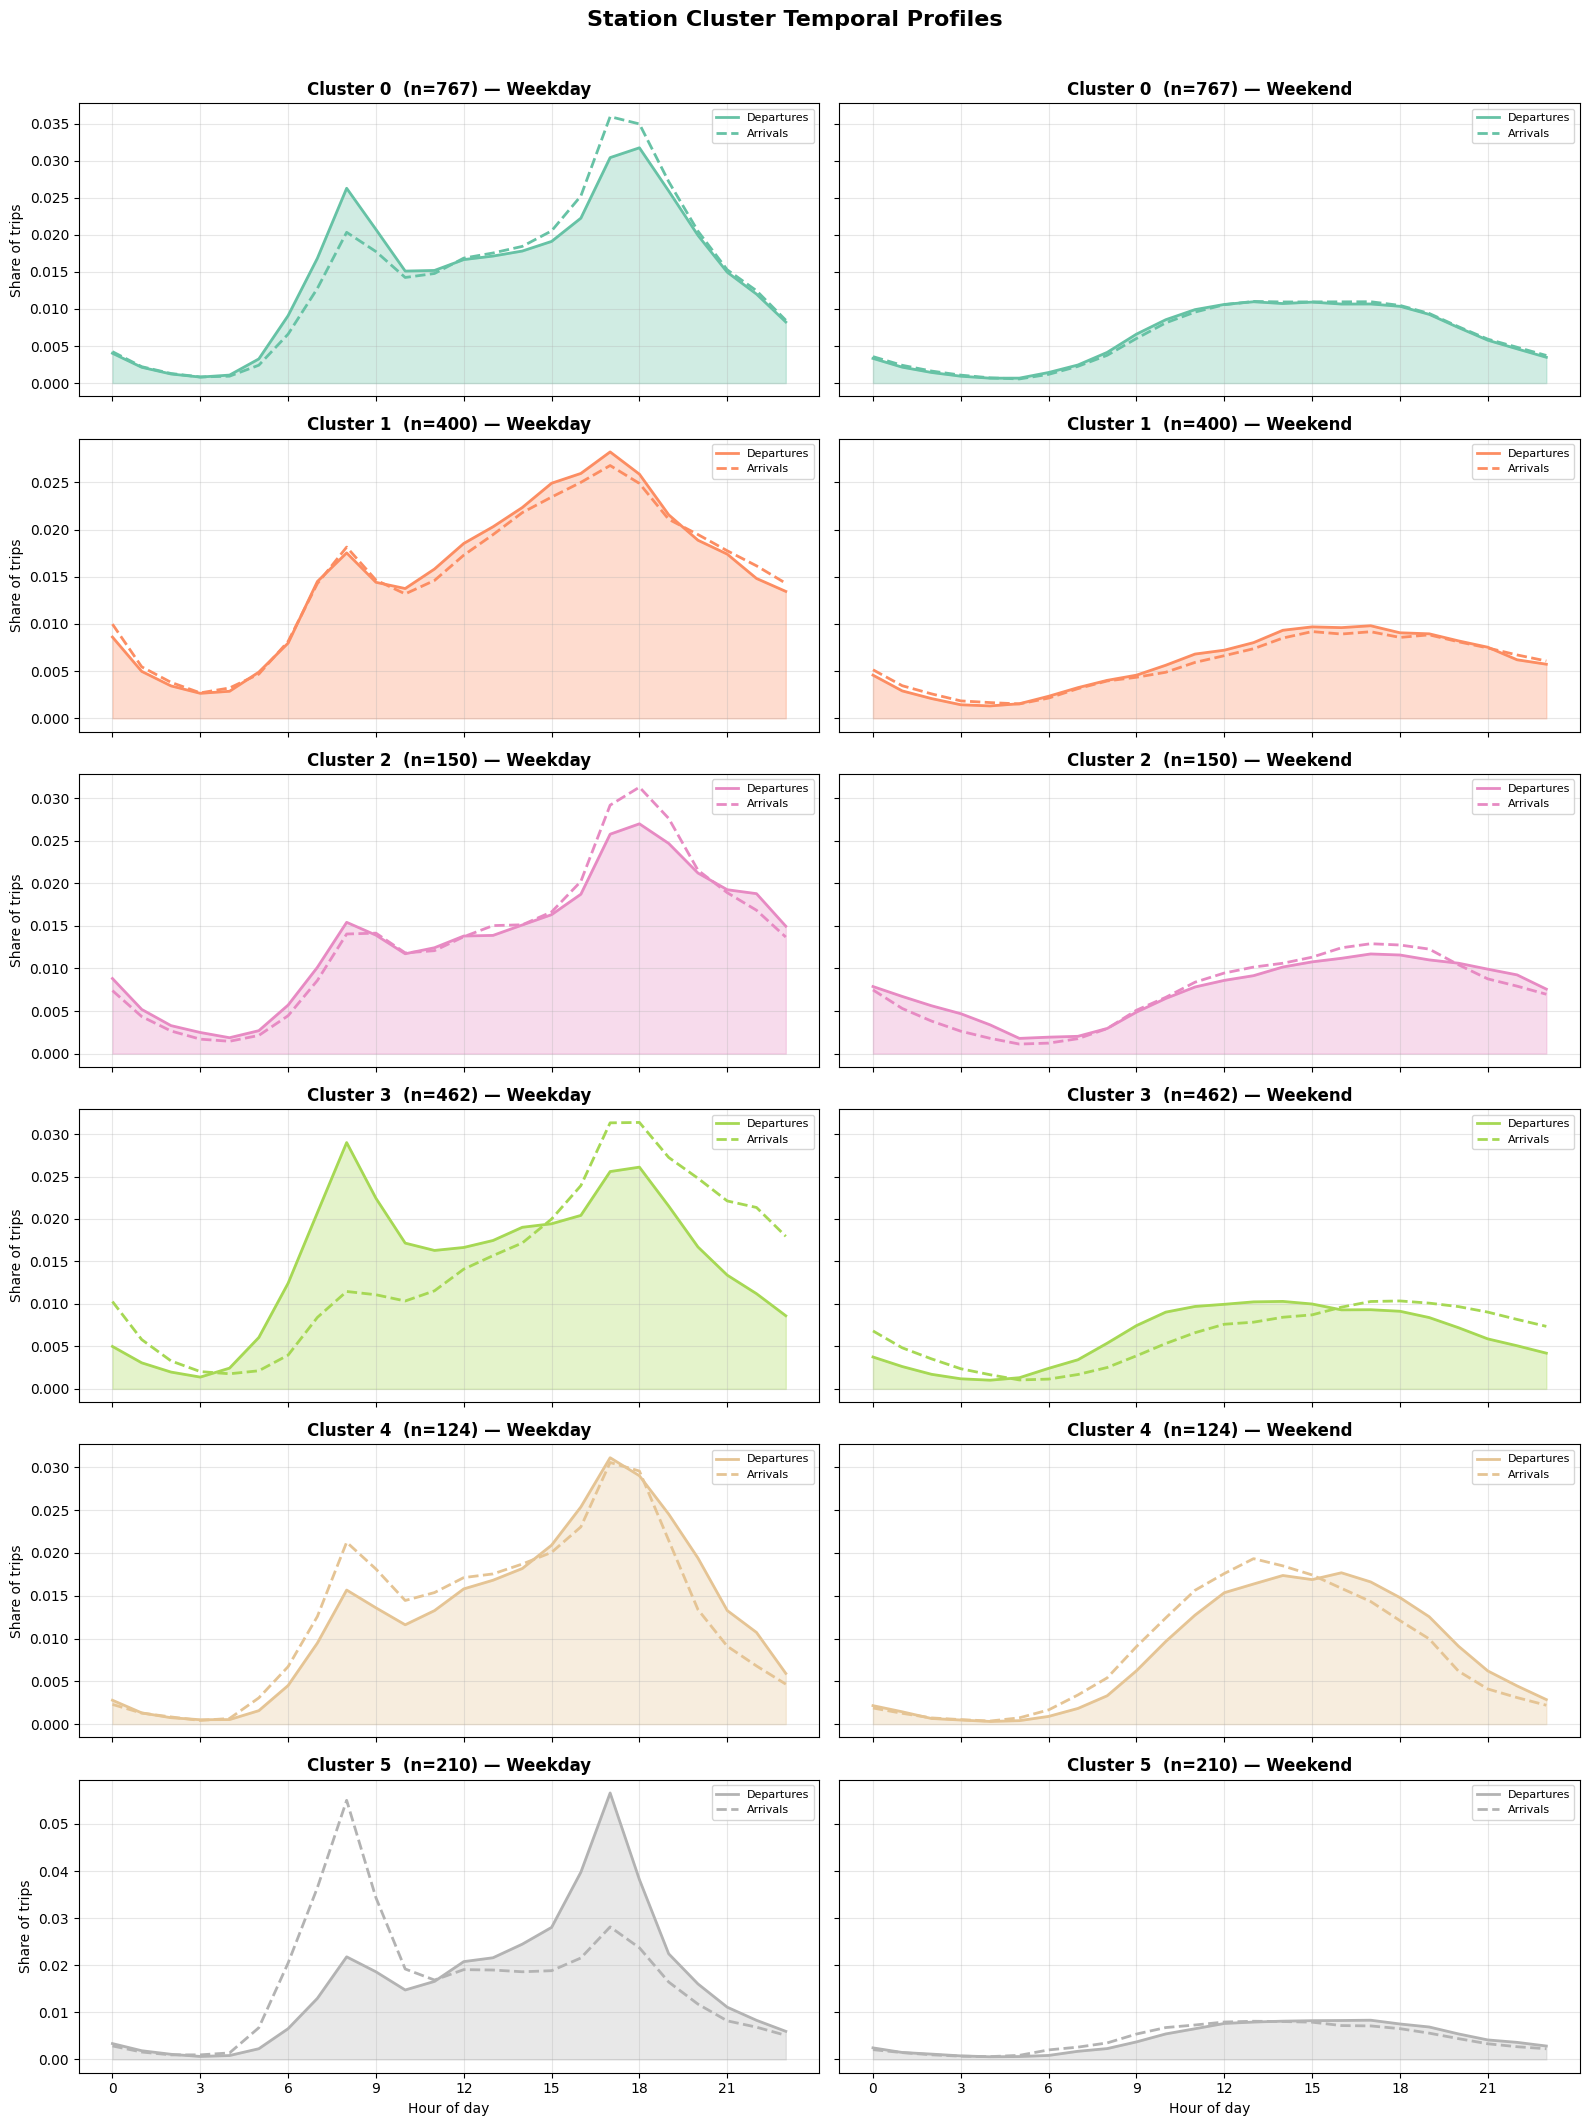

In [0]:
def plot_cluster_profiles(cluster_means, title_prefix=""):
    """Plot weekday dep/arr and weekend dep/arr for each cluster."""
    n_clusters = len(cluster_means)
    fig, axes = plt.subplots(n_clusters, 2, figsize=(16, 3.5 * n_clusters),
                             sharex=True, sharey="row")
    if n_clusters == 1:
        axes = axes.reshape(1, -1)

    hours = list(range(24))
    colors = plt.cm.Set2(np.linspace(0, 1, n_clusters))

    for i, (cluster_id, row) in enumerate(cluster_means.iterrows()):
        color = colors[i]
        n_stations = (pdf_active["cluster"] == cluster_id).sum()

        # Weekday
        ax = axes[i, 0]
        wd_dep = [row.get(f"dep_wd_{h}", 0) for h in hours]
        wd_arr = [row.get(f"arr_wd_{h}", 0) for h in hours]
        ax.fill_between(hours, wd_dep, alpha=0.3, color=color)
        ax.plot(hours, wd_dep, "-",  color=color, linewidth=2, label="Departures")
        ax.plot(hours, wd_arr, "--", color=color, linewidth=2, label="Arrivals")
        ax.set_title(f"Cluster {cluster_id}  (n={n_stations}) — Weekday", fontweight="bold")
        ax.set_ylabel("Share of trips")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(0, 24, 3))

        # Weekend
        ax = axes[i, 1]
        we_dep = [row.get(f"dep_we_{h}", 0) for h in hours]
        we_arr = [row.get(f"arr_we_{h}", 0) for h in hours]
        ax.fill_between(hours, we_dep, alpha=0.3, color=color)
        ax.plot(hours, we_dep, "-",  color=color, linewidth=2, label="Departures")
        ax.plot(hours, we_arr, "--", color=color, linewidth=2, label="Arrivals")
        ax.set_title(f"Cluster {cluster_id}  (n={n_stations}) — Weekend", fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(0, 24, 3))

    axes[-1, 0].set_xlabel("Hour of day")
    axes[-1, 1].set_xlabel("Hour of day")
    fig.suptitle(f"{title_prefix}Station Cluster Temporal Profiles", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

plot_cluster_profiles(cluster_means)

## 6. Silhouette breakdown by cluster

Shows how cohesive each cluster is — helps you decide if any cluster
should be split or merged.

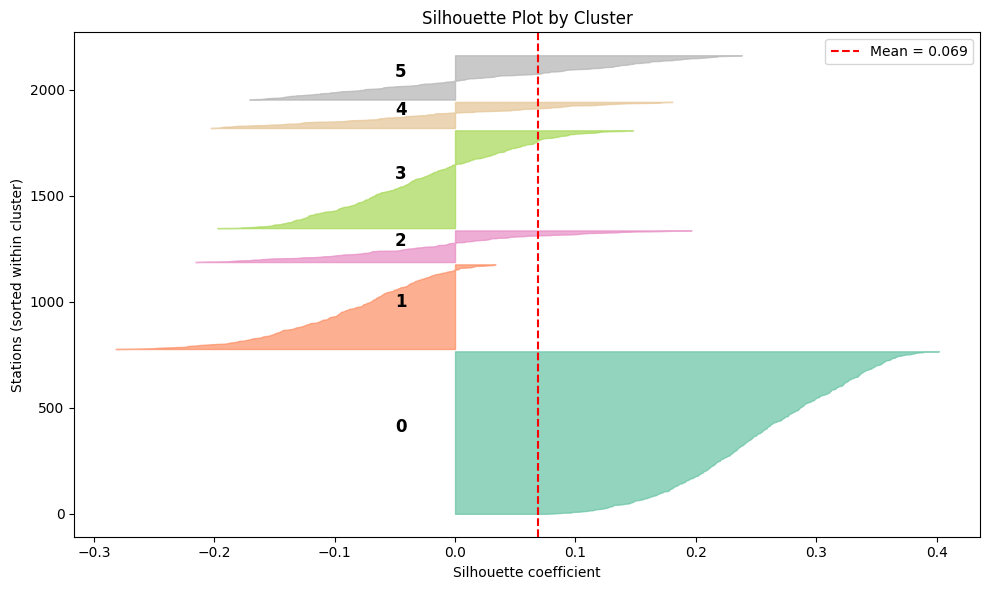

In [0]:
sil_vals = silhouette_samples(X_scaled, pdf_active["cluster"].values)
pdf_active["silhouette"] = sil_vals

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 0
colors = plt.cm.Set2(np.linspace(0, 1, CHOSEN_K))

for i in range(CHOSEN_K):
    cluster_sils = np.sort(sil_vals[pdf_active["cluster"].values == i])
    size = len(cluster_sils)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sils,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontweight="bold", fontsize=12)
    y_lower = y_upper + 10

ax.axvline(x=np.mean(sil_vals), color="red", linestyle="--", label=f"Mean = {np.mean(sil_vals):.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Stations (sorted within cluster)")
ax.set_title("Silhouette Plot by Cluster")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Map clusters onto NYC

Uses **folium** (pre-installed on Databricks) to plot every station,
colored by cluster.

In [0]:
%pip install folium

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import folium
from folium.plugins import MarkerCluster

# Drop stations with missing coordinates
map_df = pdf_active.dropna(subset=["lat", "lng"])
map_df = map_df[(map_df["lat"] > 40.5) & (map_df["lat"] < 41.0)]  # NYC bounds sanity

# Cluster color map
CLUSTER_COLORS = ["red", "blue", "green", "purple", "orange", "darkred", "cadetblue", "darkgreen"]

m = folium.Map(location=[40.735, -73.99], zoom_start=12, tiles="cartodbpositron")

for _, row in map_df.iterrows():
    c = int(row["cluster"])
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=4,
        color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['station_name']}<br>Cluster {c}<br>Trips: {row['total_trips']:.0f}",
    ).add_to(m)

# Simple legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:10px; border:2px solid grey; border-radius:5px; font-size:13px;">
<b>Station Clusters</b><br>
"""
for c in range(CHOSEN_K):
    legend_html += f'<i style="background:{CLUSTER_COLORS[c]};width:12px;height:12px;display:inline-block;border-radius:50%;margin-right:5px;"></i> Cluster {c}<br>'
legend_html += "</div>"
m.get_root().html.add_child(folium.Element(legend_html))

m

## 8. Label archetypes

In [0]:
ARCHETYPE_LABELS = {
    0: "Residential",
    1: "Commuter Hub",
    2: "Nightlife / Late Evening",
    3: "Mixed / Transitional",
    4: "Tourist / Recreational", 
    5: "Commuter Hub",
}

pdf_active["archetype"] = pdf_active["cluster"].map(ARCHETYPE_LABELS)
pdf_active[["station_name", "cluster", "archetype", "total_trips"]].sort_values("total_trips", ascending=False).head(10)

,station_name,cluster,archetype,total_trips
1094,West St & Chambers St,0,Residential,67189.0
2157,Pier 61 at Chelsea Piers,4,Tourist / Recreational,67042.0
1904,W 21 St & 6 Ave,5,Commuter Hub,66989.0
454,Lafayette St & E 8 St,0,Residential,63852.0
602,7 Ave & Central Park South,4,Tourist / Recreational,58727.0
880,9 Ave & W 33 St,5,Commuter Hub,57954.0
632,Broadway & W 58 St,4,Tourist / Recreational,57091.0
553,11 Ave & W 41 St,0,Residential,56524.0
1079,W 31 St & 7 Ave,5,Commuter Hub,56490.0
1740,Broadway & E 14 St,0,Residential,56194.0


## 9. Top stations per archetype

In [0]:

for c in range(CHOSEN_K):
    label = ARCHETYPE_LABELS.get(c, f"Cluster {c}")
    subset = pdf_active[pdf_active["cluster"] == c].nlargest(10, "total_trips")
    print(f"\n{'='*60}")
    print(f"  {label} (Cluster {c}) — Top 10 by volume")
    print(f"{'='*60}")
    for _, r in subset.iterrows():
        print(f"  {r['station_name']:45s}  {r['total_trips']:>8,.0f} trips")



  Residential (Cluster 0) — Top 10 by volume
  West St & Chambers St                            67,189 trips
  Lafayette St & E 8 St                            63,852 trips
  11 Ave & W 41 St                                 56,524 trips
  Broadway & E 14 St                               56,194 trips
  E 17 St & Broadway                               55,457 trips
  Cleveland Pl & Spring St                         54,583 trips
  University Pl & E 14 St                          53,340 trips
  W 30 St & 10 Ave                                 53,157 trips
  Metropolitan Ave & Bedford Ave                   50,587 trips
  6 Ave & W 33 St                                  49,796 trips

  Commuter Hub (Cluster 1) — Top 10 by volume
  W 41 St & 8 Ave                                  45,986 trips
  W 42 St & 8 Ave                                  24,829 trips
  Wyckoff Ave & Gates Ave                          13,414 trips
  Eastern Pkwy & Kingston Ave                      11,519 trips
  Broadway 

## 10. Save clustered stations back to Delta (optional)

Persists the station-cluster mapping so your next notebook (e.g. OD flow
analysis between archetypes) can join on it directly.

In [0]:

# Select columns to save
save_cols = ["station_name", "lat", "lng", "cluster", "archetype", "total_trips"]
save_df = pdf_active[save_cols].copy()

# pandas → Spark → Delta
sdf_clusters = spark.createDataFrame(save_df)
sdf_clusters.write.format("delta").mode("overwrite").saveAsTable("citibike.station_clusters")
print("Saved citibike.station_clusters ✅")

---
## Summary

| Step | Tool | Why |
|---|---|---|
| Hourly aggregation on 10M rows | **Spark** | Scale |
| Pivot to station × 96 features | **Spark** | Wide groupBy/pivot |
| L1 normalization + StandardScaler | **pandas/sklearn** | Station-level (small) |
| K-means + silhouette | **sklearn** | Fast, interactive tuning |
| Folium map | **folium** | Databricks renders inline |

**Next step:** Use `citibike.station_clusters` in a notebook that builds
OD flows *between* archetypes — showing how Commuter Hubs feed Residential
clusters in the evening and reverse in the morning.